In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ROOT = Path("..")
RAW = ROOT / "data" / "raw"

RAW

PosixPath('../data/raw')

In [4]:
customers = pd.read_csv(RAW / "customers.csv")
products = pd.read_csv(RAW / "products.csv")
orders = pd.read_csv(RAW / "orders.csv")
order_items = pd.read_csv(RAW / "order_items.csv")

In [5]:
print("customers:", customers.shape)
print("products:", products.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)

customers: (2512, 5)
products: (180, 5)
orders: (9000, 6)
order_items: (22632, 6)


In [6]:
customers.head()

,customer_id,customer_name,city,segment,signup_date
0,C00001,Elena Ivanova,Tomsk,New,2024-09-04
1,C00002,Alex Morozova,Saint Petersburg,Regular,2024-06-08
2,C00003,Daria Volkova,Perm,VIP,2025-01-14
3,C00004,Elena Smirnova,Kazan,Regular,2025-04-28
4,C00005,Roman Petrova,Moscow,New,2024-07-09


In [7]:
products.head()

,product_id,product_name,category,list_price,unit_cost
0,P0001,Keyboard I13,Electronics,256.68,133.31
1,P0002,Headphones K68,Electronics,264.47,124.19
2,P0003,Power Bank U68,Electronics,271.26,146.09
3,P0004,Smart Watch F77,Electronics,37.63,27.35
4,P0005,Smart Watch T44,Electronics,199.77,123.17


In [8]:
orders.head()

,order_id,customer_id,order_date,channel,payment_method,status
0,O000001,C00242,2025-08-17,Website,Card,Completed
1,O000002,C00843,2025-01-16,Website,Card,Completed
2,O000003,C00621,2025-08-01,Mobile App,Wallet,Completed
3,O000004,C00261,2025-06-24,Marketplace,SBP,Completed
4,O000005,C00734,2025-01-19,Marketplace,Card,Cancelled


In [9]:
order_items.head()

,line_id,order_id,product_id,quantity,unit_price,discount_pct
0,L0000001,O000001,P0180,2,52.22,0.0
1,L0000002,O000001,P0170,2,254.85,0.0
2,L0000003,O000001,P0021,3,71.03,0.0
3,L0000004,O000001,P0087,2,97.26,0.0
4,L0000005,O000002,P0016,2,60.22,0.0


In [10]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    2512 non-null   str  
 1   customer_name  2512 non-null   str  
 2   city           2486 non-null   str  
 3   segment        2512 non-null   str  
 4   signup_date    2512 non-null   str  
dtypes: str(5)
memory usage: 98.3 KB


In [11]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    180 non-null    str    
 1   product_name  180 non-null    str    
 2   category      180 non-null    str    
 3   list_price    180 non-null    float64
 4   unit_cost     180 non-null    float64
dtypes: float64(2), str(3)
memory usage: 7.2 KB


In [12]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        9000 non-null   str  
 1   customer_id     9000 non-null   str  
 2   order_date      9000 non-null   str  
 3   channel         9000 non-null   str  
 4   payment_method  9000 non-null   str  
 5   status          9000 non-null   str  
dtypes: str(6)
memory usage: 422.0 KB


In [13]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 22632 entries, 0 to 22631
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   line_id       22632 non-null  str    
 1   order_id      22632 non-null  str    
 2   product_id    22632 non-null  str    
 3   quantity      22632 non-null  int64  
 4   unit_price    22632 non-null  float64
 5   discount_pct  22632 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 1.0 MB


In [14]:
customers.isna().sum()

customer_id       0
customer_name     0
city             26
segment           0
signup_date       0
dtype: int64

In [15]:
products.isna().sum()

product_id      0
product_name    0
category        0
list_price      0
unit_cost       0
dtype: int64

In [16]:
orders.isna().sum()

order_id          0
customer_id       0
order_date        0
channel           0
payment_method    0
status            0
dtype: int64

In [17]:
order_items.isna().sum()

line_id         0
order_id        0
product_id      0
quantity        0
unit_price      0
discount_pct    0
dtype: int64

In [18]:
print("customers duplicates:", customers.duplicated().sum())
print("products duplicates:", products.duplicated().sum())
print("orders duplicates:", orders.duplicated().sum())
print("order_items duplicates:", order_items.duplicated().sum())

customers duplicates: 12
products duplicates: 0
orders duplicates: 0
order_items duplicates: 0


In [19]:
customers_clean = customers.drop_duplicates().copy()

In [20]:
customers_clean["city"] = customers_clean["city"].fillna("Unknown")

In [21]:
print(customers.shape)
print(customers_clean.shape)
print(customers_clean.isna().sum())

(2512, 5)
(2500, 5)
customer_id      0
customer_name    0
city             0
segment          0
signup_date      0
dtype: int64


In [22]:
customers_clean["signup_date"] = pd.to_datetime(customers_clean["signup_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])

In [23]:
print(customers_clean["signup_date"].dtype)
print(orders["order_date"].dtype)

datetime64[us]
datetime64[us]


In [24]:
sales = order_items.merge(
    products,
    on="product_id",
    how="left"
)

In [25]:
sales.head()

,line_id,order_id,product_id,quantity,unit_price,discount_pct,product_name,category,list_price,unit_cost
0,L0000001,O000001,P0180,2,52.22,0.0,Textbook T44,Books,52.22,30.80
1,L0000002,O000001,P0170,2,254.85,0.0,Novel E52,Books,254.85,161.50
2,L0000003,O000001,P0021,3,71.03,0.0,Headphones Z87,Electronics,71.03,51.81
3,L0000004,O000001,P0087,2,97.26,0.0,Serum T68,Beauty,97.26,65.10
4,L0000005,O000002,P0016,2,60.22,0.0,Keyboard D13,Electronics,60.22,40.85


In [26]:
sales = sales.merge(
    orders,
    on="order_id",
    how="left"
)

In [27]:
sales = sales.merge(
    customers_clean,
    on="customer_id",
    how="left"
)

In [28]:
sales.head()

,line_id,order_id,product_id,quantity,unit_price,discount_pct,product_name,category,list_price,unit_cost,customer_id,order_date,channel,payment_method,status,customer_name,city,segment,signup_date
0,L0000001,O000001,P0180,2,52.22,0.0,Textbook T44,Books,52.22,30.80,C00242,2025-08-17,Website,Card,Completed,Alex Sokolov,Omsk,Regular,2025-03-30
1,L0000002,O000001,P0170,2,254.85,0.0,Novel E52,Books,254.85,161.50,C00242,2025-08-17,Website,Card,Completed,Alex Sokolov,Omsk,Regular,2025-03-30
2,L0000003,O000001,P0021,3,71.03,0.0,Headphones Z87,Electronics,71.03,51.81,C00242,2025-08-17,Website,Card,Completed,Alex Sokolov,Omsk,Regular,2025-03-30
3,L0000004,O000001,P0087,2,97.26,0.0,Serum T68,Beauty,97.26,65.10,C00242,2025-08-17,Website,Card,Completed,Alex Sokolov,Omsk,Regular,2025-03-30
4,L0000005,O000002,P0016,2,60.22,0.0,Keyboard D13,Electronics,60.22,40.85,C00843,2025-01-16,Website,Card,Completed,Kirill Ivanov,Novosibirsk,New,2025-12-30


In [29]:
sales.shape

(22632, 19)

In [30]:
sales["revenue"] = sales["quantity"] * sales["unit_price"]

In [31]:
sales["cost"] = sales["quantity"] * sales["unit_cost"]

In [32]:
sales["profit"] = sales["revenue"] - sales["cost"]

In [33]:
sales["margin_pct"] = np.where(
    sales["revenue"] > 0,
    sales["profit"] / sales["revenue"] * 100,
    0
)

In [34]:
sales["year_month"] = sales["order_date"].dt.to_period("M").astype(str)

In [35]:
sales[
    ["order_id", "product_name", "quantity", "revenue", "cost", "profit", "margin_pct"]
].head()

,order_id,product_name,quantity,revenue,cost,profit,margin_pct
0,O000001,Textbook T44,2,104.44,61.60,42.84,41.018767
1,O000001,Novel E52,2,509.70,323.00,186.70,36.629390
2,O000001,Headphones Z87,3,213.09,155.43,57.66,27.058989
3,O000001,Serum T68,2,194.52,130.20,64.32,33.066009
4,O000002,Keyboard D13,2,120.44,81.70,38.74,32.165394


In [36]:
completed = sales[sales["status"] == "Completed"].copy()

In [37]:
total_revenue = completed["revenue"].sum()
total_revenue

np.float64(6654279.35)

In [38]:
total_orders = completed["order_id"].nunique()
total_orders

7969

In [39]:
total_customers = completed["customer_id"].nunique()
total_customers

2380

In [40]:
average_order_value = total_revenue / total_orders
average_order_value

np.float64(835.0206236667085)

In [41]:
total_profit = completed["profit"].sum()
total_profit

np.float64(2362534.71)

In [42]:
kpi = pd.DataFrame({
    "Metric": [
        "Revenue",
        "Orders",
        "Customers",
        "Average Order Value",
        "Profit"
    ],
    "Value": [
        round(total_revenue, 2),
        total_orders,
        total_customers,
        round(average_order_value, 2),
        round(total_profit, 2)
    ]
})

kpi

,Metric,Value
0,Revenue,6654279.35
1,Orders,7969.00
2,Customers,2380.00
3,Average Order Value,835.02
4,Profit,2362534.71


In [43]:
monthly_sales = (
    completed
    .groupby("year_month", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        orders=("order_id", "nunique")
    )
)

monthly_sales.head()

,year_month,revenue,profit,orders
0,2025-01,424292.16,150512.45,496
1,2025-02,315100.40,111085.03,380
2,2025-03,372371.95,134947.58,429
3,2025-04,385265.45,135661.47,454
4,2025-05,371663.04,130857.35,451


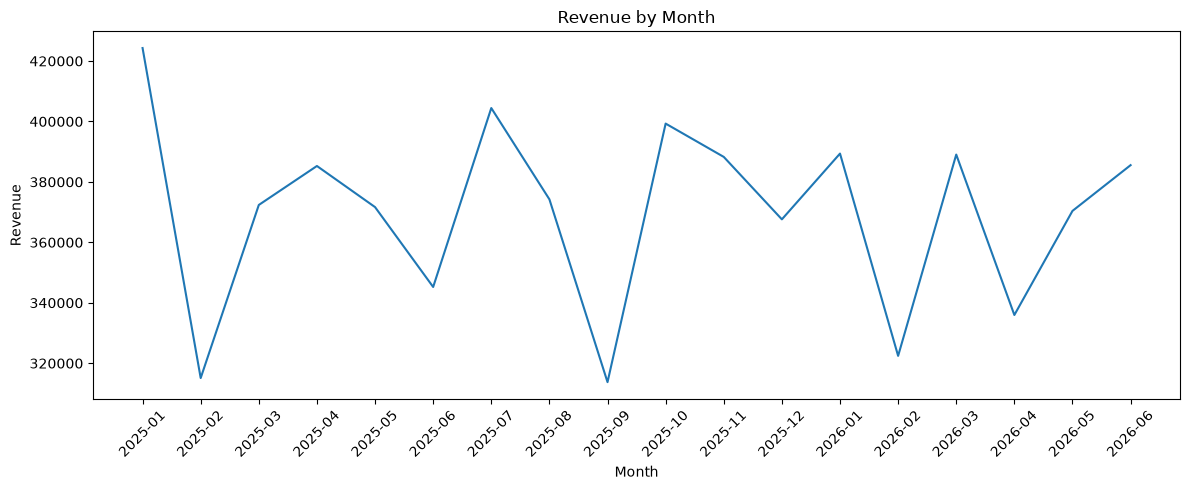

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["year_month"], monthly_sales["revenue"])
plt.xticks(rotation=45)
plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [45]:
category_sales = (
    completed
    .groupby("category", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
)

category_sales

,category,revenue,profit,quantity
2,Clothing,1355213.47,525058.20,6833
4,Home,1186864.70,433422.64,6720
1,Books,1100467.57,380373.86,6727
0,Beauty,1065105.16,363819.44,6609
3,Electronics,981882.83,315027.39,6624
5,Sports,964745.62,344833.18,6465


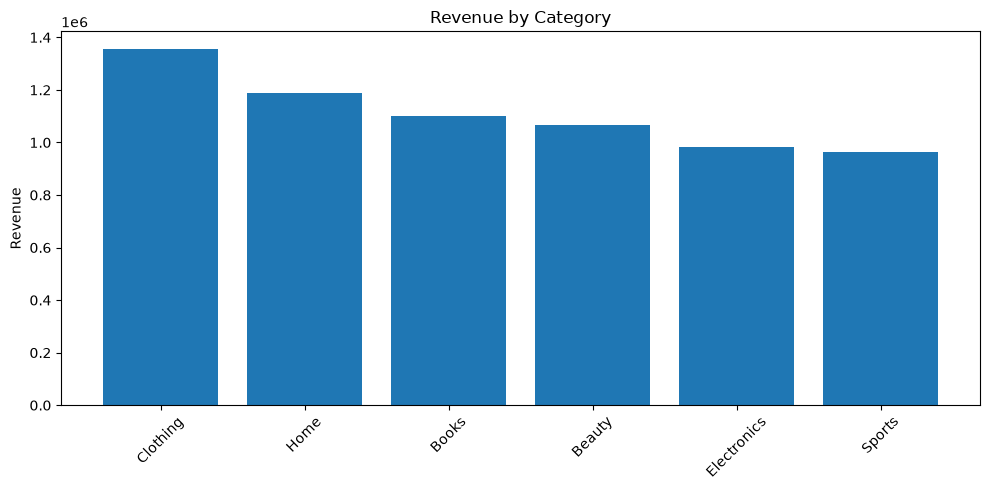

In [46]:
plt.figure(figsize=(10, 5))
plt.bar(category_sales["category"], category_sales["revenue"])
plt.xticks(rotation=45)
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [47]:
channel_sales = (
    completed
    .groupby("channel", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        profit=("profit", "sum")
    )
    .sort_values("revenue", ascending=False)
)

channel_sales

,channel,revenue,orders,profit
2,Website,3017048.79,3581,1064422.91
1,Mobile App,2635480.26,3186,939986.20
0,Marketplace,1001750.30,1202,358125.60


In [48]:
city_sales = (
    completed
    .groupby("city", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
)

city_sales.head(10)

,city,revenue,orders,customers
1,Moscow,1976153.66,2379,711
5,Saint Petersburg,1243051.59,1482,437
2,Novosibirsk,604248.00,714,214
0,Kazan,467511.00,556,161
10,Yekaterinburg,460324.39,581,178
8,Ufa,403082.11,494,139
6,Samara,400068.71,457,144
7,Tomsk,372846.44,432,131
4,Perm,355907.57,423,126
3,Omsk,308747.97,370,114


In [49]:
top_products = (
    completed
    .groupby("product_name", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        profit=("profit", "sum"),
        quantity=("quantity", "sum")
    )
    .sort_values("revenue", ascending=False)
    .head(10)
)

top_products

,product_name,revenue,profit,quantity
47,Dress Z72,82306.35,36241.80,285
36,Cream E38,82014.69,26622.85,266
61,Guide Z37,78824.00,21485.60,280
78,Jeans R19,78418.72,29420.50,249
81,Jeans Z52,78022.06,32371.96,255
155,Sneakers E67,76379.59,28070.35,238
178,Yoga Mat S93,76256.21,14326.23,238
10,Blanket I22,74734.99,34470.19,228
3,Backpack O10,73293.00,22813.81,239
106,Mouse W86,71328.74,33838.13,219


In [50]:
segment_sales = (
    completed
    .groupby("segment", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique")
    )
    .sort_values("revenue", ascending=False)
)

segment_sales

,segment,revenue,customers,orders
0,New,3282720.97,1157,3932
1,Regular,2772899.24,997,3327
2,VIP,598659.14,226,710


In [51]:
order_status = (
    orders["status"]
    .value_counts()
    .reset_index()
)

order_status.columns = ["status", "orders"]

order_status

,status,orders
0,Completed,7969
1,Cancelled,584
2,Returned,447


In [53]:
from pathlib import Path

ROOT = Path("..")
PROCESSED = ROOT / "data" / "processed"

In [54]:
PROCESSED.mkdir(parents=True, exist_ok=True)

sales.to_csv(
    PROCESSED / "sales_clean.csv",
    index=False
)

In [55]:
(PROCESSED / "sales_clean.csv").exists()

True